In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, models, utils, datasets
import numpy as np
from sklearn.metrics import confusion_matrix

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Text(0.5, 1.0, '2')

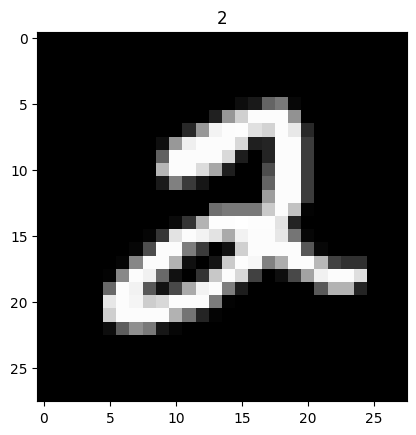

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()
plt.imshow(X_train[5], cmap='gray')
plt.title(y_train[5])

In [3]:
print(X_train.shape)

(60000, 28, 28)


In [4]:
X_train = X_train.flatten().reshape(60000, 784).astype('float32')
X_test = X_test.flatten().reshape(10000, 784).astype('float32')

X_train /= 255
X_test /= 255

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [5]:
# Reduzir dimensionalidade preservando 95% de sua variancia, para ocupar menos espaço. Cada instância terá pouco mais de 150 features, reduzindo 20% do tamanho
#from sklearn.decomposition import PCA
#pca = PCA(n_components = 300) #ou 0.95 (porém neste caso X_test fica com amostras a menos e dá erro)
#X_train_pca = pca.fit_transform(X_train)
#X_test_pca = pca.fit_transform(X_test)

In [6]:
#transformando target em dummy (onehotencoder)
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [7]:
y_train[5]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [8]:
from keras import regularizers

# dropout - técnica de regularização NN baseada em ensemble (p. 258-268 Livro Goodfellow)
def train_nn(hidden_layers, neurons, activation_function_hidden, drop_out, epochs):
    #https://www.tensorflow.org/guide/keras/sequential_model?hl=pt-br
    model = keras.Sequential()

    #primeira camada oculta + camada de entrada
    model.add(layers.Dense(units=neurons, activation=activation_function_hidden, input_dim=784))
    model.add(layers.Dropout(drop_out)) #regularização

    #camadas ocultas adicionais com dropout
    for n in range(hidden_layers):
        model.add(layers.Dense(units=neurons, activation=activation_function_hidden))
        model.add(layers.Dropout(drop_out))

    #camada de saída com 10 saídas -  multiclasse com função de ativação softmax (iremos ver em regressão logística)
    model.add(layers.Dense(units=10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    """Use this crossentropy loss function when there are two or more label classes.
    We expect labels to be provided in a one_hot representation. If you want to provide labels as integers,
    please use SparseCategoricalCrossentropy loss. There should be num_classes floating point values per feature, i.e.,
    the shape of both y_pred and y_true are [batch_size, num_classes].
    """

    model.summary()

    histdata = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test))
    print(histdata.history.keys())

    # plot loss
    plt.subplot(211)
    plt.title('Loss')
    plt.plot(histdata.history['loss'], label='train')
    plt.plot(histdata.history['val_loss'], label='test')
    plt.legend()

    # plot precision
    plt.subplot(212)
    plt.title('Accuracy')
    plt.plot(histdata.history['accuracy'], label='train')
    plt.plot(histdata.history['val_accuracy'], label='test')
    plt.legend()
    plt.show()

    #loss = plt.plot(histdata.history['val_loss']) #diferenca entre predito e observado
    #pr = plt.plot(histdata.history['val_precision']) #diferença entre erros e acertos
    _, train_acc = model.evaluate(X_train, y_train, verbose=0)
    _, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))
    #plt.savefig('loss.png')
    plt.close()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,274 (51.85 KB)

 Trainable params: 13,274 (51.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8421 - loss: 0.5160 - val_accuracy: 0.9151 - val_loss: 0.2952
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9255 - loss: 0.2585 - val_accuracy: 0.9339 - val_loss: 0.2243
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9384 - loss: 0.2092 - val_accuracy: 0.9446 - val_loss: 0.1975
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9468 - loss: 0.1823 - val_accuracy: 0.9510 - val_loss: 0.1749
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9514 - loss: 0.1646 - val_accuracy: 0.9521 - val_loss: 0.1664
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9562 - loss: 0.1502 - val_accuracy: 0.9539 - val_loss: 0.1632
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9585 - loss: 0.1409 - val_accuracy: 0.9555 - val_loss: 0.1559
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9605 - loss: 0.1337 -

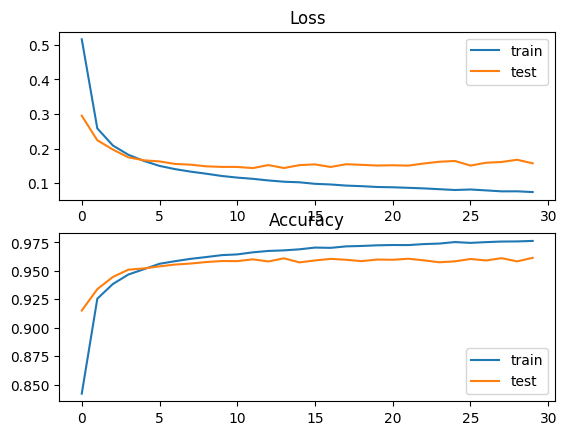

Train: 0.980, Test: 0.961


In [9]:
train_nn(2, 16,'relu',0.0, 30)

In [10]:
"""
hidden_layers = [1, 2, 3]
neurons = [10,32,64]
activation = ['relu', 'tanh']
drop_out = [0.1, 0.2]
epochs = [5, 10, 20]

# 108 modelos

for layers in hidden_layers:
    for n in neurons:
        for act in activation:
            for drop in drop_out:
                for e in epochs:
                    train_nn(layers, n, act, drop, e)
"""

"\nhidden_layers = [1, 2, 3]\nneurons = [10,32,64]\nactivation = ['relu', 'tanh']\ndrop_out = [0.1, 0.2]\nepochs = [5, 10, 20]\n\n# 108 modelos\n\nfor layers in hidden_layers:\n    for n in neurons:\n        for act in activation:\n            for drop in drop_out:\n                for e in epochs:\n                    train_nn(layers, n, act, drop, e)\n"

In [11]:
#Instalação do Optuna
!pip -q install optuna

import optuna

print("Optuna carregado com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 13.7 MB/s eta 0:00:00
Optuna carregado com sucesso!


In [12]:
#Função de treinamento adaptada para o Optuna
def build_model_optuna(hidden_layers, neurons, activation_function_hidden, drop_out):
    model = keras.Sequential()

    #Mesma ideia da primeira camada usada em train_nn()
    model.add(
        layers.Dense(
            units=neurons,
            activation=activation_function_hidden,
            input_dim=784
        )
    )
    model.add(layers.Dropout(drop_out))

    #Camadas ocultas adicionais
    for _ in range(hidden_layers):
        model.add(
            layers.Dense(
                units=neurons,
                activation=activation_function_hidden
            )
        )
        model.add(layers.Dropout(drop_out))

    #Mesma saída do código-base
    model.add(layers.Dense(units=10, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [13]:
#Função objetivo
def objective(trial):

    hidden_layers = trial.suggest_categorical(
        "hidden_layers",
        [1, 2, 3]
    )

    neurons = trial.suggest_categorical(
        "neurons",
        [10, 32, 64]
    )

    activation = trial.suggest_categorical(
        "activation",
        ["relu", "tanh"]
    )

    drop_out = trial.suggest_categorical(
        "drop_out",
        [0.1, 0.2]
    )

    epochs = trial.suggest_categorical(
        "epochs",
        [5, 10, 20]
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    model = build_model_optuna(
        hidden_layers,
        neurons,
        activation,
        drop_out
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.10,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    return max(history.history["val_accuracy"])

In [14]:
#Busca dos melhores hiperparâmetros
N_TRIALS = 15

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=N_TRIALS
)

print("\n--- RESULTADOS DA OTIMIZAÇÃO ---")
print(
    f"Melhor acurácia de validação: "
    f"{study.best_value:.4f} "
    f"({study.best_value*100:.2f}%)"
)

print("\nMelhores hiperparâmetros encontrados:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

[I 2026-09-05 14:59:11,922] A new study created in memory with name: no-name-58e4b8ac-957e-440d-8416-66a9dc397287
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-09-05 15:00:12,911] Trial 0 finished with value: 0.9164999723434448 and parameters: {'hidden_layers': 2, 'neurons': 10, 'activation': 'tanh', 'drop_out': 0.2, 'epochs': 10, 'batch_size': 32}. Best is trial 0 with value: 0.9164999723434448.
[I 2026-09-05 15:01:03,512] Trial 1 finished with value: 0.9663333296775818 and parameters: {'hidden_layers': 2, 'neurons': 32, 'activation': 'tanh', 'drop_out': 0.2, 'epochs': 20, 'batch_size': 64}. Best is trial 1 with value: 0.9663333296775818.
[I 2026-09-05 15:01:57,358] Trial 2 finished with value: 0


--- RESULTADOS DA OTIMIZAÇÃO ---
Melhor acurácia de validação: 0.9812 (98.12%)

Melhores hiperparâmetros encontrados:
hidden_layers: 1
neurons: 64
activation: relu
drop_out: 0.1
epochs: 20
batch_size: 128


In [15]:
#Quadro comparativo dos trials
results_df = study.trials_dataframe()

cols = [
    "number",
    "value",
    "state"
] + [
    c for c in results_df.columns
    if c.startswith("params_")
]

display(
    results_df
    .sort_values("value", ascending=False)
    [cols]
    .head(15)
)

,number,value,state,params_activation,params_batch_size,params_drop_out,params_epochs,params_hidden_layers,params_neurons
11,11,0.981167,COMPLETE,relu,128,0.1,20,1,64
10,10,0.980833,COMPLETE,relu,128,0.1,20,1,64
12,12,0.980000,COMPLETE,relu,128,0.1,20,1,64
14,14,0.979333,COMPLETE,relu,128,0.1,20,1,64
5,5,0.979333,COMPLETE,relu,64,0.1,20,1,64
4,4,0.978833,COMPLETE,relu,64,0.2,20,2,64
13,13,0.978833,COMPLETE,relu,128,0.1,20,1,64
6,6,0.976500,COMPLETE,tanh,64,0.1,10,1,64
8,8,0.975500,COMPLETE,relu,64,0.2,10,2,64
1,1,0.966333,COMPLETE,tanh,64,0.2,20,2,32


In [16]:
#Treinamento do melhor modelo

best = study.best_params

final_model = build_model_optuna(
    hidden_layers=best["hidden_layers"],
    neurons=best["neurons"],
    activation_function_hidden=best["activation"],
    drop_out=best["drop_out"]
)

final_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_final = final_model.fit(
    X_train,
    y_train,
    validation_split=0.10,
    epochs=best["epochs"],
    batch_size=best["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8505 - loss: 0.5045 - val_accuracy: 0.9538 - val_loss: 0.1709
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9328 - loss: 0.2220 - val_accuracy: 0.9650 - val_loss: 0.1243
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9483 - loss: 0.1703 - val_accuracy: 0.9692 - val_loss: 0.1008
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9586 - loss: 0.1387 - val_accuracy: 0.9728 - val_loss: 0.0920
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9635 - loss: 0.1204 - val_accuracy: 0.9762 - val_loss: 0.0848
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9678 - loss: 0.1050 - val_accuracy: 0.9737 - val_loss: 0.0823
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9702 - loss: 0.0979 - val_accuracy: 0.9775 - val_loss: 0.0785
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9724 - loss: 0.0877 - val_accuracy:

In [17]:
#Avaliação final no conjunto de teste
train_loss, train_acc = final_model.evaluate(
    X_train,
    y_train,
    verbose=0
)

test_loss, test_acc = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Acurácia no treino: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Loss no treino: {train_loss:.4f}")

print(f"\nAcurácia no teste: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Loss no teste: {test_loss:.4f}")

Acurácia no treino: 0.9883 (98.83%)
Loss no treino: 0.0406

Acurácia no teste: 0.9777 (97.77%)
Loss no teste: 0.0764


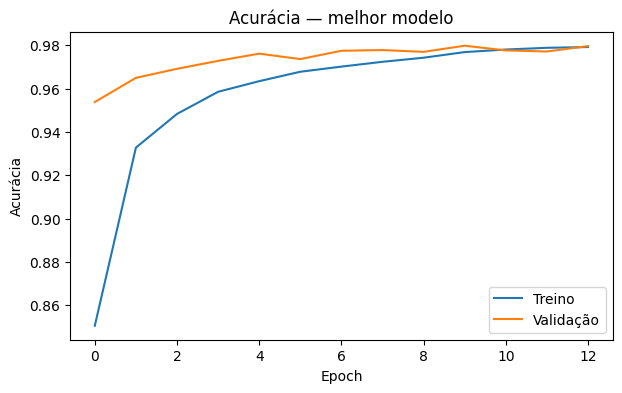

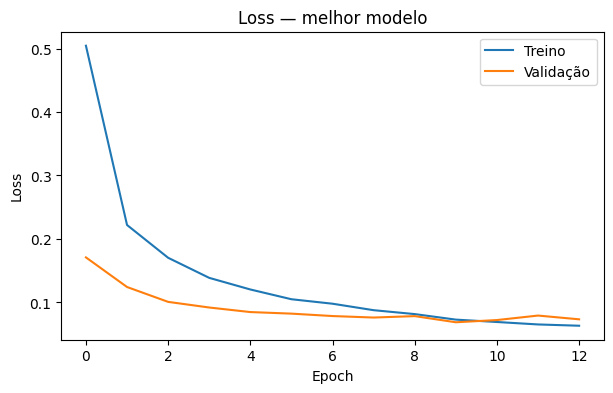

In [21]:
#Curvas de aprendizagem
plt.figure(figsize=(7,4))
plt.plot(
    history_final.history["accuracy"],
    label="Treino"
)
plt.plot(
    history_final.history["val_accuracy"],
    label="Validação"
)
plt.xlabel("Epoch")
plt.ylabel("Acurácia")
plt.title("Acurácia — melhor modelo")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(
    history_final.history["loss"],
    label="Treino"
)
plt.plot(
    history_final.history["val_loss"],
    label="Validação"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss — melhor modelo")
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0     0.9710    0.9918    0.9813       980
           1     0.9903    0.9903    0.9903      1135
           2     0.9814    0.9719    0.9766      1032
           3     0.9724    0.9752    0.9738      1010
           4     0.9777    0.9807    0.9792       982
           5     0.9787    0.9765    0.9776       892
           6     0.9812    0.9781    0.9796       958
           7     0.9718    0.9737    0.9728      1028
           8     0.9742    0.9692    0.9717       974
           9     0.9770    0.9683    0.9726      1009

    accuracy                         0.9777     10000
   macro avg     0.9776    0.9776    0.9775     10000
weighted avg     0.9777    0.9777    0.9777     10000



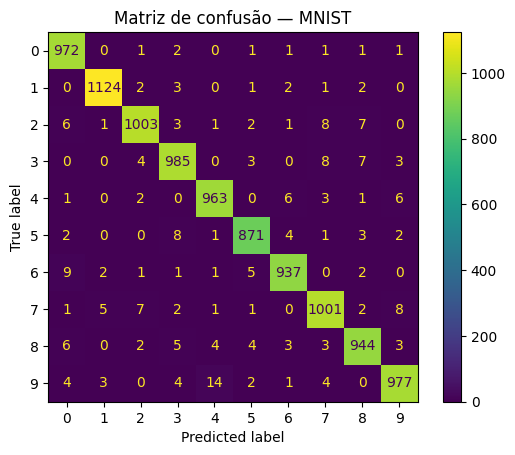

In [19]:
#Matriz de confusão e métricas por classe
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

y_prob = final_model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

#Como y_test está em one-hot, retorna-se ao rótulo inteiro
y_true = np.argmax(
    y_test,
    axis=1
)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

cm = confusion_matrix(
    y_true,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(10))
).plot(values_format="d")

plt.title("Matriz de confusão — MNIST")
plt.show()

In [20]:
#Exportação do modelo
final_model.save(
    "mnist_otimizado_codigo_base.keras"
)

print(
    "Modelo salvo como "
    "mnist_otimizado_codigo_base.keras"
)

Modelo salvo como mnist_otimizado_codigo_base.keras
